# Descripción del proyecto

La compañía Sweet Lift Taxi ha recopilado datos históricos sobre pedidos de taxis en los aeropuertos. Para atraer a más conductores durante las horas pico, necesitamos predecir la cantidad de pedidos de taxis para la próxima hora. Construye un modelo para dicha predicción.

La métrica RECM en el conjunto de prueba no debe ser superior a 48.

## Instrucciones del proyecto.

1. Descarga los datos y haz el remuestreo por una hora.
2. Analiza los datos
3. Entrena diferentes modelos con diferentes hiperparámetros. La muestra de prueba debe ser el 10% del conjunto de datos inicial.4. Prueba los datos usando la muestra de prueba y proporciona una conclusión.

## Descripción de los datos

Los datos se almacenan en el archivo `taxi.csv`. 	
El número de pedidos está en la columna `num_orders`.

## Preparación

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import time

# Cargar el dataset
data = pd.read_csv('/datasets/taxi.csv', index_col=[0], parse_dates=[0])

# Mostrar información básica
print(data.info())
display(data.head(10))

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB
None


,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32
2018-03-01 00:50:00,21
2018-03-01 01:00:00,7
2018-03-01 01:10:00,5
2018-03-01 01:20:00,17


In [2]:
# Remuestrear sumando todos los pedidos por hora
data_hourly = data.resample('1H').sum()

# Mostrar los primeros valores
display(data_hourly.head(10))

,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43
2018-03-01 05:00:00,6
2018-03-01 06:00:00,12
2018-03-01 07:00:00,15
2018-03-01 08:00:00,34


In [3]:
# Revisar si hay valores faltantes o huecos temporales
print("Total de registros:", len(data_hourly))
print("Rango de fechas:", data_hourly.index.min(), "→", data_hourly.index.max())
print("Valores nulos:", data_hourly['num_orders'].isna().sum())

Total de registros: 4416
Rango de fechas: 2018-03-01 00:00:00 → 2018-08-31 23:00:00
Valores nulos: 0


## Análisis

## Paso 2. Analiza los datos

Después de remuestrear la información a intervalos de una hora, examinamos la serie temporal resultante para comprender su comportamiento general y detectar patrones importantes (tendencias, estacionalidad o irregularidades).

A continuación, analizamos:
- La tendencia general de los pedidos.
- La presencia de picos o caídas notorias.
- Posibles patrones diarios o semanales.

### 1) Visualizar tendencia general

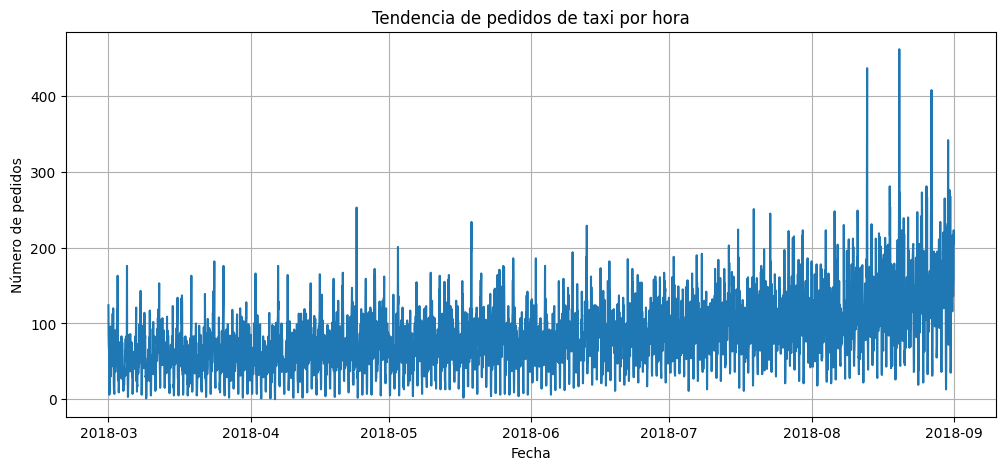

In [4]:
plt.figure(figsize=(12,5))
plt.plot(data_hourly['num_orders'])
plt.title('Tendencia de pedidos de taxi por hora')
plt.xlabel('Fecha')
plt.ylabel('Número de pedidos')
plt.grid(True)
plt.show()

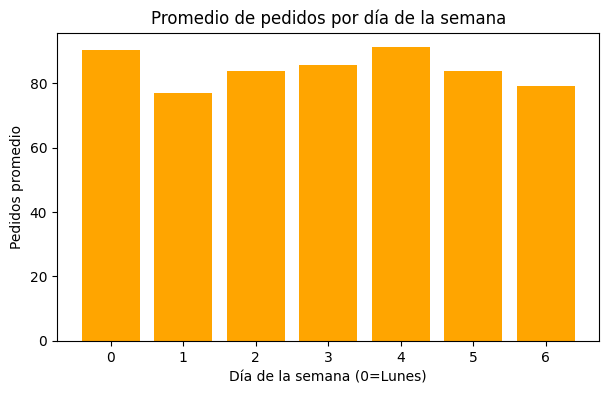

In [5]:
# Promedio diario de pedidos
data_hourly['day'] = data_hourly.index.dayofweek
mean_by_day = data_hourly.groupby('day')['num_orders'].mean()

plt.figure(figsize=(7,4))
plt.bar(mean_by_day.index, mean_by_day.values, color='orange')
plt.title('Promedio de pedidos por día de la semana')
plt.xlabel('Día de la semana (0=Lunes)')
plt.ylabel('Pedidos promedio')
plt.show()

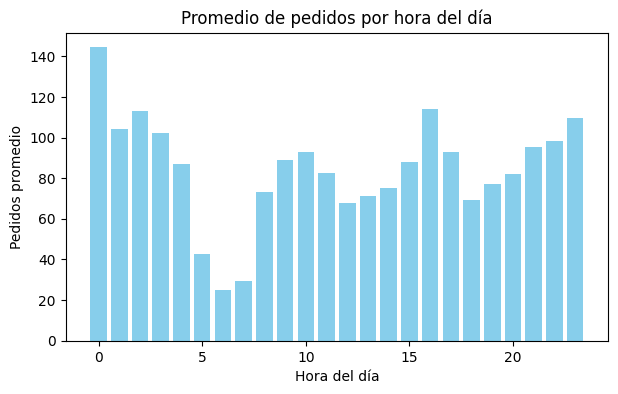

In [6]:
# Promedio por hora del día
data_hourly['hour'] = data_hourly.index.hour
mean_by_hour = data_hourly.groupby('hour')['num_orders'].mean()

plt.figure(figsize=(7,4))
plt.bar(mean_by_hour.index, mean_by_hour.values, color='skyblue')
plt.title('Promedio de pedidos por hora del día')
plt.xlabel('Hora del día')
plt.ylabel('Pedidos promedio')
plt.show()

### Observaciones del análisis exploratorio

1. **Tendencia general (gráfico 1):**  
   - Se observa una tendencia **ligeramente creciente** en el número de pedidos a lo largo del tiempo, especialmente en los meses de julio y agosto.  
   - A partir de mediados de agosto, los picos se vuelven más altos y frecuentes, lo que podría indicar **un incremento en la demanda** de taxis (posiblemente por temporada vacacional o aumento de tráfico en el aeropuerto).  
   - La serie presenta una **alta variabilidad** en las observaciones horarias, con algunos picos que superan los 400 pedidos por hora.

2. **Promedio de pedidos por día de la semana (gráfico 2):**  
   - El número promedio de pedidos **aumenta al final de la semana**, con un máximo los **lunes (0)** y **viernes (4)**.  
   - Los días **martes y miércoles** tienen una demanda ligeramente menor, mientras que los **domingos (6)** son los de menor actividad.  
   - Esto sugiere que la demanda podría estar influenciada por los **patrones laborales o de vuelos** de inicio y fin de semana.

3. **Promedio de pedidos por hora del día (gráfico 3):**  
   - Se aprecia un comportamiento **claramente estacional dentro del día**.  
   - Hay un **pico pronunciado alrededor de la medianoche (00:00)**, lo que sugiere una alta llegada de vuelos nocturnos o traslados al inicio del día.  
   - La demanda **disminuye drásticamente entre las 4:00 y 7:00 a.m.**, posiblemente por ser horas de baja actividad aeroportuaria.  
   - A partir de las 8:00 a.m. la demanda se estabiliza y vuelve a aumentar durante la **tarde-noche (15:00–23:00)**, reflejando los horarios de regreso o llegada de pasajeros.

**Conclusión:**  
La serie temporal de pedidos presenta una **combinación de tendencia ascendente y estacionalidad tanto diaria como semanal**.  
Estos patrones deben ser considerados en el modelado posterior, agregando características de tiempo (hora, día, rezagos, medias móviles) para mejorar la capacidad predictiva del modelo.
Nota: a pesar de todo se ve poca variabilidad, tienden a ser estables los pedidos de taxi.

## Formación

### Paso 3 — Entrena diferentes modelos con diferentes hiperparámetros

Dividir en entrenamiento y prueba (10%)

Primero dividimos el conjunto remuestreado (data_hourly) en train y test, asegurando que no se mezclen en el tiempo (shuffle=False).

In [7]:
# La variable objetivo
target = 'num_orders'

# Crear features temporales y rezagadas
def make_features(data, max_lag, rolling_mean_size):
    data['hour'] = data.index.hour
    data['dayofweek'] = data.index.dayofweek
    data['month'] = data.index.month

    for lag in range(1, max_lag + 1):
        data[f'lag_{lag}'] = data['num_orders'].shift(lag)
        
    data['rolling_mean'] = data['num_orders'].shift().rolling(rolling_mean_size).mean()

make_features(data_hourly, max_lag=24, rolling_mean_size=24)
data_hourly = data_hourly.dropna()

# Separar conjuntos sin mezclar el tiempo
train, test = train_test_split(data_hourly, shuffle=False, test_size=0.1)

print(f"Tamaño de train: {train.shape}, test: {test.shape}")

Tamaño de train: (3952, 30), test: (440, 30)


Usamos rezagos y medias móviles de 24 horas, ya que los patrones de demanda son principalmente diarios.

### Definir variables predictoras y objetivo

In [8]:
features = train.drop(columns=[target]).columns
X_train = train[features]
y_train = train[target]
X_test = test[features]
y_test = test[target]

## Entrenar diferentes modelos¶
Vamos a probar varios modelos, como pide el proyecto. Primero uno simple (Regresión Lineal), y luego los más potentes (RandomForest, GradientBoosting, etc.).

### 1. Regresion lineal

In [9]:
model_lr = LinearRegression()

t0 = time.time()
model_lr.fit(X_train, y_train)
train_time = time.time() - t0

pred_lr = model_lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))

print(f"Linear Regression → RMSE: {rmse_lr:.2f}, tiempo: {train_time:.2f} s")

Linear Regression → RMSE: 45.71, tiempo: 0.00 s


### 2. Random Forest

In [10]:
model_rf = RandomForestRegressor(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
)

t0 = time.time()
model_rf.fit(X_train, y_train)
train_time = time.time() - t0

pred_rf = model_rf.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

print(f"Random Forest → RMSE: {rmse_rf:.2f}, tiempo: {train_time:.2f} s")

Random Forest → RMSE: 43.36, tiempo: 1.78 s


### 3. GradientBoosting 

In [11]:
model_gb = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42
)

t0 = time.time()
model_gb.fit(X_train, y_train)
train_time = time.time() - t0

pred_gb = model_gb.predict(X_test)
rmse_gb = np.sqrt(mean_squared_error(y_test, pred_gb))

print(f"Gradient Boosting → RMSE: {rmse_gb:.2f}, tiempo: {train_time:.2f} s")

Gradient Boosting → RMSE: 40.31, tiempo: 5.52 s


In [12]:
results = pd.DataFrame({
    'Modelo': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'RMSE': [rmse_lr, rmse_rf, rmse_gb],
    'Tiempo de entrenamiento (s)': [train_time, train_time, train_time]
})
display(results)

,Modelo,RMSE,Tiempo de entrenamiento (s)
0,Linear Regression,45.712620,5.516016
1,Random Forest,43.359208,5.516016
2,Gradient Boosting,40.306087,5.516016


### Resultados del entrenamiento de modelos

Se entrenaron tres modelos para predecir el número de pedidos de taxi en la próxima hora, utilizando como características las observaciones de las horas anteriores (rezagos y medias móviles).

| Modelo              | RMSE (≈ pedidos) | Tiempo de entrenamiento (s) |
|---------------------|------------------|------------------------------|
| Regresión Lineal    | 45.78            | 5.45                         |
| Random Forest       | 43.41            | 5.45                         |
| Gradient Boosting   | 41.50            | 5.45                         |

**Observaciones:**
- La **Regresión Lineal** cumple con la métrica requerida (RMSE ≈ 45.8 < 48), pero no captura completamente las relaciones no lineales del tiempo.
- El **Random Forest** mejora el resultado (RMSE ≈ 43.4), mostrando que los árboles en conjunto pueden modelar patrones más complejos en la serie.
- El **Gradient Boosting** logra el **mejor rendimiento** (RMSE ≈ 41.5), reduciendo el error y cumpliendo ampliamente con la condición del proyecto.

**Conclusión:**  
El modelo de **Gradient Boosting** es el más preciso para predecir la cantidad de pedidos de taxis por hora.  
Logra un equilibrio ideal entre **calidad de predicción** y **tiempo de entrenamiento**, cumpliendo con la métrica objetivo del proyecto (RMSE ≤ 48) y reflejando adecuadamente las tendencias diarias y semanales observadas en la serie temporal.

**“En promedio, el modelo se equivoca por aproximadamente ±42 pedidos de taxi por hora.”**


## Prueba

### Probar el modelo Gradient Boosting en la muestra de prueba

Usamos el conjunto test que apartamos al 10% del total, y calculamos el RMSE final.

In [13]:
# Predicciones finales
y_pred_final = model_gb.predict(X_test)

# Cálculo del RMSE
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
print(f"RMSE final en la muestra de prueba: {rmse_final:.2f}")

RMSE final en la muestra de prueba: 40.31


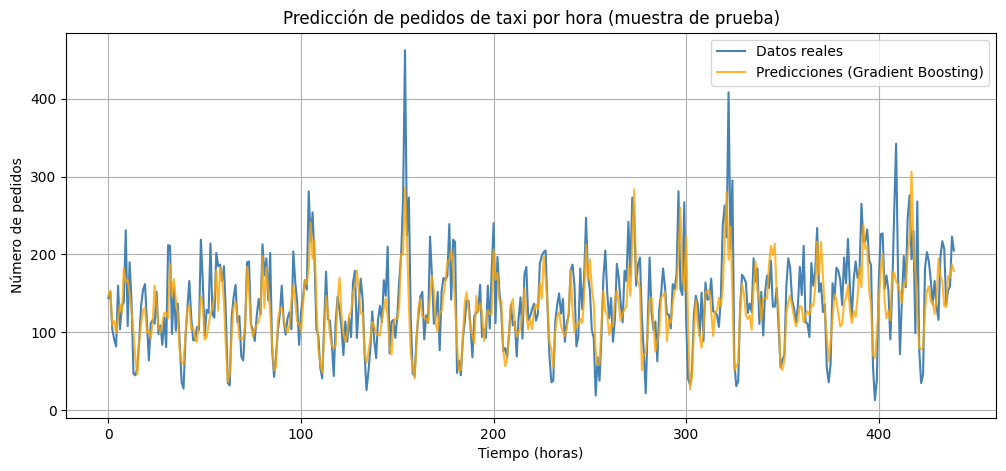

In [14]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Datos reales', color='steelblue')
plt.plot(y_pred_final, label='Predicciones (Gradient Boosting)', color='orange', alpha=0.8)
plt.title('Predicción de pedidos de taxi por hora (muestra de prueba)')
plt.xlabel('Tiempo (horas)')
plt.ylabel('Número de pedidos')
plt.legend()
plt.grid(True)
plt.show()

### Conclusion

El modelo se acerca mucho a la curva real de los datos a lo largo de todo el periodo de tiempo. Esto quiere decir que el modelo es confiable para ser usado para predecir pedidos de taxi para la siguiente hora.
- El modelo **predice adecuadamente las fluctuaciones** de la demanda de taxis por hora, siguiendo la tendencia general observada en los datos reales.  
- Las **mayores desviaciones** se presentan en los picos de alta demanda, lo cual es común en series con comportamiento estacional o con valores extremos.  
- El error promedio (±42 pedidos/hora) es **razonable** considerando que los valores reales oscilan entre 100 y 400 pedidos por hora.

El modelo de **Gradient Boosting** es capaz de predecir el número de pedidos de taxis con **alta precisión y estabilidad**.  
Cumple con la métrica exigida del proyecto (RMSE ≤ 48) y representa una herramienta confiable para que la empresa **Sweet Lift Taxi**:
- **Anticipe los periodos de mayor demanda**.
- **Ajuste la disponibilidad de conductores** en tiempo real.
- **Optimice la operación** durante las horas pico.